# HomeWork #3 - Neo4j

In [ ]:
# Spazzini Michael - 732040
import pandas as pd
import matplotlib.pyplot as plt
import ast
from neo4j import GraphDatabase
from itertools import combinations
from collections import defaultdict

# --- CONFIGURAZIONE ---
URI = "neo4j://127.0.0.1:7687"
AUTH = ("neo4j", "neo4jneo4j")
PAPER_CSV_PATH = "./resources/arxiv_papers.csv"
PAPER_TOPICS_CSV_PATH = "./resources/papers_with_topics.csv"
TOPIC_DEFS_CSV_PATH = "./resources/topic_definitions.csv"

# Inizializziamo il driver (verrà usato in tutte le celle successive)
driver = GraphDatabase.driver(URI, auth=AUTH)

def check_connection():
    try:
        driver.verify_connectivity()
        return "Connessione riuscita!"
    except Exception as e:
        return f"Errore di connessione: {e}"

check_connection()

'Connessione riuscita!'

In [15]:
# Sezione per caricamento dati
def load_csv_to_dataframe(file_path):
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Errore nel caricamento del file: {e}")
        return None

# Caricamento Papers
df_papers = load_csv_to_dataframe(PAPER_CSV_PATH)
# Estrazione data (YYYY-MM-DD) dal timestamp e sostituzione di 'published' con 'date'
df_papers['published'] = df_papers['published'].str[:10]
df_papers = df_papers.rename(columns={'published': 'date'})
# Conversione stringa "['Autore A', 'Autore B']" in lista Python vera
df_papers['authors_list'] = df_papers['authors'].apply(ast.literal_eval)

#print(df_papers.head())

#  Caricamento Definizioni Topic
df_topics_def = load_csv_to_dataframe(TOPIC_DEFS_CSV_PATH)

#  Caricamento Relazioni Paper-Topic
df_papers_topics = load_csv_to_dataframe(PAPER_TOPICS_CSV_PATH)
# Convertiamo le stringhe delle liste top_topics in oggetti Python reali (per dopo)
df_papers_topics['top_topics'] = df_papers_topics['top_topics'].apply(ast.literal_eval)
df_papers_topics['top_probabilities'] = df_papers_topics['top_probabilities'].apply(ast.literal_eval)

print(f"Dati pronti: {len(df_papers)} articoli caricati in memoria.")


Dati pronti: 8000 articoli caricati in memoria.


In [17]:
# Creazione Database (se non esiste già)
with driver.session(database="system") as session:
    session.run("CREATE DATABASE homework IF NOT EXISTS")

In [18]:
def import_papers_data(tx, data):
    query = """
    UNWIND $data AS row
    MERGE (p:Paper {url: row.url})
    SET p.title = row.title,
        p.abstract = row.abstract,
        p.date = date(row.date)

    WITH p, row
    UNWIND row.authors AS author_name
    MERGE (a:Author {name: author_name})
    MERGE (a)-[:AUTHORED]->(p)
    """
    tx.run(query, data=data)

papers_data = df_papers[['url', 'title', 'abstract', 'date', 'authors_list']].to_dict('records')

for d in papers_data:
    d['authors'] = d.pop('authors_list')

with driver.session(database="homework") as session:
    session.run("CREATE CONSTRAINT paper_url IF NOT EXISTS FOR (p:Paper) REQUIRE p.url IS UNIQUE")
    session.run("CREATE CONSTRAINT author_name IF NOT EXISTS FOR (a:Author) REQUIRE a.name IS UNIQUE")

    print("Inizio importazione Paper e Author...")
    session.execute_write(import_papers_data, papers_data)
    print("Paper e Author importati correttamente.")


Inizio importazione Paper e Author...
Paper e Author importati correttamente.


In [19]:
def import_topics(tx, data):
    query = """
    UNWIND $data AS row
    MERGE (t:Topic {topic_id: row.topic_id})
    SET t.name = row.name,
        t.representation = row.representation
    """
    tx.run(query, data=data)


def import_paper_topics(tx, data):
    query = """
    UNWIND $data AS row
    MATCH (p:Paper {url: row.url})
    UNWIND range(0, size(row.top_topics) - 1) AS i
    MATCH (t:Topic {topic_id: row.top_topics[i]})
    MERGE (p)-[r:ON_TOPIC]->(t)
    SET r.probability = row.top_probabilities[i]
    """
    tx.run(query, data=data)


topics_data = (
    df_topics_def[['Topic', 'Name', 'Representation']]
    .rename(columns={
        'Topic': 'topic_id',
        'Name': 'name',
        'Representation': 'representation'
    })
    .to_dict('records')
)

paper_topics_data = df_papers_topics[['url', 'top_topics', 'top_probabilities']].to_dict('records')


with driver.session(database="homework") as session:
    session.run("""
        CREATE CONSTRAINT topic_id IF NOT EXISTS
        FOR (t:Topic)
        REQUIRE t.topic_id IS UNIQUE
    """)

    session.execute_write(import_topics, topics_data)
    session.execute_write(import_paper_topics, paper_topics_data)

    print("Topic e relazioni ON_TOPIC importati correttamente.")

Topic e relazioni ON_TOPIC importati correttamente.


In [21]:
def create_coauthorship_safe(tx, authors_list):
    query = """
    UNWIND $authors AS name1
    UNWIND $authors AS name2
    WITH name1, name2
    WHERE name1 < name2
    MATCH (a1:Author {name: name1})
    MATCH (a2:Author {name: name2})
    MERGE (a1)-[r:COAUTHORED_WITH]->(a2)
    ON CREATE SET r.papers_in_common = 1
    ON MATCH SET r.papers_in_common = r.papers_in_common + 1
    """
    tx.run(query, authors=authors_list)

with driver.session(database="homework") as session:
    print("Inizio creazione relazioni COAUTHORED_WITH...")
    count = 0

    for authors in df_papers['authors_list']:
        authors = sorted(set(authors))
        if len(authors) > 1:
            session.execute_write(create_coauthorship_safe, authors)

        count += 1
        if count % 1000 == 0:
            print(f"Processati {count} papers...")

    print("Relazioni COAUTHORED_WITH completate.")


Inizio creazione relazioni COAUTHORED_WITH...
Processati 1000 papers...
Processati 2000 papers...
Processati 3000 papers...
Processati 4000 papers...
Processati 5000 papers...
Processati 6000 papers...
Processati 7000 papers...
Processati 8000 papers...
Relazioni COAUTHORED_WITH completate.


In [23]:
# Calcolo Similarità tra Topic (usando la rappresentazione vettoriale)
# Topic1 e Topic2 sono dizionari {topic_id: probability}
# Esempio: {37: 0.3459, 108: 0.0302, 3: 0.0224}
def ruzicka_similarity(topics1, topics2):
    common_topics = set(topics1.keys()) & set(topics2.keys())
    if not common_topics:
        return 0.0

    all_topics = set(topics1.keys()) | set(topics2.keys())
    numerator = sum(min(topics1.get(t, 0.0), topics2.get(t, 0.0)) for t in all_topics)
    denominator = sum(max(topics1.get(t, 0.0), topics2.get(t, 0.0)) for t in all_topics)

    return numerator / denominator if denominator > 0 else 0.0


def import_similar_topics_batch(tx, data):
    query = """
    UNWIND $data AS row
    MATCH (p1:Paper {url: row.url1})
    MATCH (p2:Paper {url: row.url2})
    MERGE (p1)-[r:SIMILAR_TOPIC]->(p2)
    SET r.score = row.score
    """
    tx.run(query, data=data)


paper_topic_map = {}
topic_to_papers = defaultdict(list)

for _, row in df_papers_topics.iterrows():
    topic_probs = dict(zip(row['top_topics'], row['top_probabilities']))
    paper_topic_map[row['url']] = topic_probs

    for topic in row['top_topics']:
        topic_to_papers[topic].append(row['url'])


candidate_pairs = set()

for topic, papers in topic_to_papers.items():
    unique_papers = sorted(set(papers))
    if len(unique_papers) > 1:
        for url1, url2 in combinations(unique_papers, 2):
            candidate_pairs.add((url1, url2))


similarities_data = []

for idx, (url1, url2) in enumerate(candidate_pairs, start=1):
    sim = ruzicka_similarity(paper_topic_map[url1], paper_topic_map[url2])

    if sim > 0:
        similarities_data.append({
            "url1": url1,
            "url2": url2,
            "score": sim
        })

    if idx % 10000 == 0:
        print(f"... calcolate {idx} coppie candidate")


batch_size = 1000

with driver.session(database="homework") as session:
    for i in range(0, len(similarities_data), batch_size):
        batch = similarities_data[i:i + batch_size]
        session.execute_write(import_similar_topics_batch, batch)

        if i % 10000 == 0:
            print(f"... importate {i + len(batch)} relazioni SIMILAR_TOPIC")

print(f"Relazioni SIMILAR_TOPIC create: {len(similarities_data)}")


... calcolate 10000 coppie candidate
... calcolate 20000 coppie candidate
... calcolate 30000 coppie candidate
... calcolate 40000 coppie candidate
... calcolate 50000 coppie candidate
... calcolate 60000 coppie candidate
... calcolate 70000 coppie candidate
... calcolate 80000 coppie candidate
... calcolate 90000 coppie candidate
... calcolate 100000 coppie candidate
... calcolate 110000 coppie candidate
... calcolate 120000 coppie candidate
... calcolate 130000 coppie candidate
... calcolate 140000 coppie candidate
... calcolate 150000 coppie candidate
... calcolate 160000 coppie candidate
... calcolate 170000 coppie candidate
... calcolate 180000 coppie candidate
... calcolate 190000 coppie candidate
... calcolate 200000 coppie candidate
... calcolate 210000 coppie candidate
... calcolate 220000 coppie candidate
... calcolate 230000 coppie candidate
... calcolate 240000 coppie candidate
... calcolate 250000 coppie candidate
... calcolate 260000 coppie candidate
... calcolate 270000 

In [24]:
# Estrarre i primi 5 autori come numero di articoli di cui sono autori o coautori
query_top_authors = """
MATCH (a:Author)-[:AUTHORED]->(p:Paper)
RETURN a.name, count(p) AS num_papers
ORDER BY num_papers DESC
LIMIT 5
"""
with driver.session(database="homework") as session:
    result = session.run(query_top_authors)
    print("Top 5 Autori per numero di articoli:")
    for record in result:
        print(f"{record['a.name']}: {record['num_papers']} articoli")

Top 5 Autori per numero di articoli:
Wei Wang: 19 articoli
Yang Li: 19 articoli
Yang Liu: 18 articoli
Xin Wang: 15 articoli
H. Vincent Poor: 13 articoli


In [ ]:
# Verifica mesi di pubblicazione dei paper
query = """
MATCH (p:Paper)
WHERE p.date IS NOT NULL
RETURN min(p.date.year) AS min_year, max(p.date.year) AS max_year, count(p) AS total
"""

with driver.session(database="homework") as session:
    print(session.run(query).single())

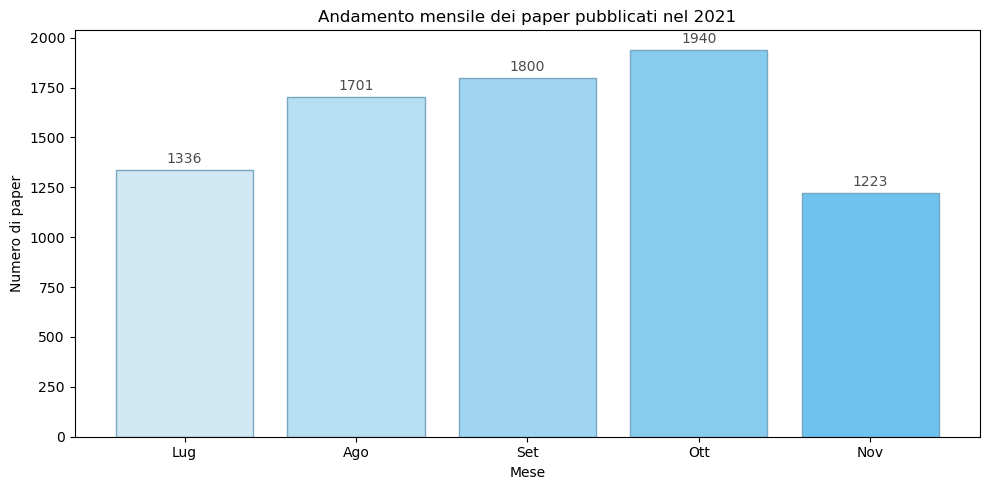

In [32]:
query = """
MATCH (p:Paper)
WHERE p.date IS NOT NULL
RETURN p.date.month AS month, count(p) AS num_papers
ORDER BY month
"""

with driver.session(database="homework") as session:
    result = session.run(query)
    df_months = pd.DataFrame([dict(record) for record in result])

month_labels = {
    1: "Gen", 2: "Feb", 3: "Mar", 4: "Apr", 5: "Mag", 6: "Giu",
    7: "Lug", 8: "Ago", 9: "Set", 10: "Ott", 11: "Nov", 12: "Dic"
}

df_months["month_name"] = df_months["month"].map(month_labels)

colors = ["#cfe8f3", "#b7dff2", "#9fd5f0", "#87ccef", "#6fc2ed"]

plt.figure(figsize=(10, 5))
bars = plt.bar(
    df_months["month_name"],
    df_months["num_papers"],
    color=colors[:len(df_months)],
    edgecolor="#7aa6c2"
)

plt.xlabel("Mese")
plt.ylabel("Numero di paper")
plt.title("Andamento mensile dei paper pubblicati nel 2021")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#4a4a4a"
    )

plt.tight_layout()
plt.show()

In [36]:
def get_author_papers(session):
    query = """
    MATCH (a:Author)-[:AUTHORED]->(p:Paper)
    RETURN a.name AS author, collect(p.url) AS papers
    """
    result = session.run(query)
    return {record["author"]: record["papers"] for record in result}


def get_paper_authors(session):
    query = """
    MATCH (a:Author)-[:AUTHORED]->(p:Paper)
    RETURN p.url AS paper, collect(a.name) AS authors
    """
    result = session.run(query)
    return {record["paper"]: record["authors"] for record in result}


def get_paper_similarities(session):
    query = """
    MATCH (p1:Paper)-[r:SIMILAR_TOPIC]->(p2:Paper)
    RETURN p1.url AS url1, p2.url AS url2, r.score AS score
    """
    result = session.run(query)

    sim_map = {}
    similar_pairs = []

    for record in result:
        u1 = record["url1"]
        u2 = record["url2"]
        score = record["score"]

        sim_map[(u1, u2)] = score
        sim_map[(u2, u1)] = score
        similar_pairs.append((u1, u2))

    return sim_map, similar_pairs


def compute_author_similarity(papers1, papers2, paper_sim_map):
    if not papers1 or not papers2:
        return 0.0

    total = 0.0

    for p1 in papers1:
        for p2 in papers2:
            if p1 == p2:
                total += 1.0
            else:
                total += paper_sim_map.get((p1, p2), 0.0)

    return total / (len(papers1) * len(papers2))


def save_author_similarity_batch(tx, rows):
    query = """
    UNWIND $rows AS row
    MATCH (a1:Author {name: row.author1})
    MATCH (a2:Author {name: row.author2})
    MERGE (a1)-[r:SIMILAR_AUTHOR]->(a2)
    SET r.score = row.similarity
    """
    tx.run(query, rows=rows)


with driver.session(database="homework") as session:
    author_papers = get_author_papers(session)
    paper_authors = get_paper_authors(session)
    paper_sim_map, similar_paper_pairs = get_paper_similarities(session)

candidate_pairs = set()

# Candidati da stesso paper
for authors in paper_authors.values():
    authors = sorted(set(authors))
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            candidate_pairs.add((authors[i], authors[j]))

# Candidati da paper simili
for p1, p2 in similar_paper_pairs:
    authors1 = paper_authors.get(p1, [])
    authors2 = paper_authors.get(p2, [])

    for a1 in authors1:
        for a2 in authors2:
            if a1 == a2:
                continue
            pair = tuple(sorted((a1, a2)))
            candidate_pairs.add(pair)

print(f"Coppie candidate generate: {len(candidate_pairs)}")

rows = []
batch_size = 1000
threshold = 0.1

with driver.session(database="homework") as session:
    for idx, (author1, author2) in enumerate(candidate_pairs, start=1):
        papers1 = author_papers.get(author1, [])
        papers2 = author_papers.get(author2, [])

        sim = compute_author_similarity(papers1, papers2, paper_sim_map)

        if sim > threshold:
            rows.append({
                "author1": author1,
                "author2": author2,
                "similarity": sim
            })

        if idx % 10000 == 0:
            print(f"... processate {idx} coppie candidate")

        if len(rows) >= batch_size:
            session.execute_write(save_author_similarity_batch, rows)
            rows = []

    if rows:
        session.execute_write(save_author_similarity_batch, rows)

print("Relazioni SIMILAR_AUTHOR create correttamente.")

Coppie candidate generate: 67662815
... processate 10000 coppie candidate
... processate 20000 coppie candidate
... processate 30000 coppie candidate
... processate 40000 coppie candidate
... processate 50000 coppie candidate
... processate 60000 coppie candidate
... processate 70000 coppie candidate
... processate 80000 coppie candidate
... processate 90000 coppie candidate
... processate 100000 coppie candidate
... processate 110000 coppie candidate
... processate 120000 coppie candidate
... processate 130000 coppie candidate
... processate 140000 coppie candidate
... processate 150000 coppie candidate
... processate 160000 coppie candidate
... processate 170000 coppie candidate
... processate 180000 coppie candidate
... processate 190000 coppie candidate
... processate 200000 coppie candidate
... processate 210000 coppie candidate
... processate 220000 coppie candidate
... processate 230000 coppie candidate
... processate 240000 coppie candidate
... processate 250000 coppie candidat

In [ ]:
def print_database_stats():
    print("Statistiche:")

    queries = {
        "Nodi Topic": "MATCH (n:Topic) RETURN count(n) AS count",
        "Nodi Paper": "MATCH (n:Paper) RETURN count(n) AS count",
        "Nodi Author": "MATCH (n:Author) RETURN count(n) AS count",
        "Relazioni AUTHORED": "MATCH ()-[r:AUTHORED]->() RETURN count(r) AS count",
        "Relazioni ON_TOPIC": "MATCH ()-[r:ON_TOPIC]->() RETURN count(r) AS count",
        "Relazioni COAUTHORED_WITH": "MATCH ()-[r:COAUTHORED_WITH]->() RETURN count(r) AS count",
        "Relazioni SIMILAR_TOPIC": "MATCH ()-[r:SIMILAR_TOPIC]->() RETURN count(r) AS count",
        "Relazioni SIMILAR_AUTHOR": "MATCH ()-[r:SIMILAR_AUTHOR]->() RETURN count(r) AS count"
    }

    try:
        with driver.session(database="homework") as session:
            for label, query in queries.items():
                result = session.run(query).single()
                count = result["count"] if result else 0
                print(f"{label:26}: {count}")
    except Exception as e:
        print(f"Errore: {e}")



print_database_stats()
# Spazzini Michael - 732040


Statistiche:
Nodi Topic                : 128
Nodi Paper                : 8000
Nodi Author               : 37603
Relazioni AUTHORED        : 44459
Relazioni ON_TOPIC        : 24000
Relazioni COAUTHORED_WITH : 1422486
Relazioni SIMILAR_TOPIC   : 1691926
Relazioni SIMILAR_AUTHOR  : 23284913
